## Regression analysis 

In [ ]:
import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
import geopandas as gpd

from elasticsearch import Elasticsearch

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

### Merge the data sources for analysis 

This is the comments dataset (our remote database) and the applications dataset (Planning London Datahub accessed via elasticsearch). 

In [2]:
# Comments dataset
cs = Comments()
comment_df = cs.read_all().copy()
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,88955,Barnet,23/5019/FUL_1,23/5019/FUL,17 Wessex Gardens London NW11 9RS,Objects,2023-11-27,I am writing to voice my objection to the plan...,2025-04-10,51.571780,-0.208190,I am writing to voice my objection to the plan...,E09000003,-0.419751
1,85042,Barnet,23/2868/FUL_62,23/2868/FUL,2 swynford gardens London Nw44xl,Objects,2023-08-23,I live next to university. The roads in this a...,2025-04-09,51.588843,-0.234453,I live next to . The roads in this area alread...,E09000003,-0.441330
2,92284,Brent,22/2560_18,22/2560,"34 Yates Court, 228 Willesden Lane, Willesden,...",Objects,2022-07-31,I object to this planning permission for sever...,2025-04-10,51.546390,-0.216050,I object to this planning permission for sever...,E09000005,-0.061040
3,107978,Ealing,214950FUL_66,214950FUL,21 Cowper Road London W3 6PZ W3 6PZ,Objects,2021-09-15,This development is not in keeping with the sc...,2025-05-01,51.509600,-0.264540,This development is not in keeping with the sc...,E09000009,-0.594107
4,80435,Southwark,24/AP/0413_3,24/AP/0413,None,Objects,2024-04-09,I am writing to formally object to the plannin...,2025-04-09,NaN,NaN,I am writing to formally object to the plannin...,None,-0.220412


This is the list of applications which was used for webscraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

In [5]:
# Run the formatting functions 
application_df = ppf.format_df(application_df)
application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

In [6]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


Pull a bit more information on the planning applications using ElasticSearch to access the Planning London Datahub. 

In [9]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [10]:
pld_df = ppf.format_df(pld_df)
pld_df = ppf.add_housing_type(pld_df)

### MERGE!

Merge and match across data sources. 

In [11]:
df = pd.merge(application_df, pld_df[['lpa_app_no', 'housing_type']], left_on='lpa_app_no', right_on='lpa_app_no', how='left')

In [12]:
df.columns

Index(['lpa_app_no', 'valid_date', 'decision_date', 'borough',
       'total_no_proposed_residential_units', 'total_no_affordable_units',
       'site_area', 'habitable_rooms_density', 'pp_id', 'uprn', 'status',
       'decision', 'street_name', 'site_name', 'site_number', 'polygon',
       'wgs84_polygon', 'description', 'comment_count', 'outcome',
       'housing_type'],
      dtype='object')

### Random Forest classifier 

Here implement a random forest classifier to predict if applications will receive comments (True/False), based on a set of variables. 

In [13]:
# add a binary column for comment truth - as this is something I want to try and predict 
df['comment_truth'] = np.where(df['comment_count'] > 0, 1, 0)
df.head()

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,...,street_name,site_name,site_number,polygon,wgs84_polygon,description,comment_count,outcome,housing_type,comment_truth
0,24/02204/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,...,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...,1,Permitted,Market housing,1
1,25/0089,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,...,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...,0,Permitted,Market housing,0
2,24/1783,NaT,NaT,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,...,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...,5,Not Permitted,Market housing,1
3,25/00205/PRECOU,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,...,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...,0,Not Permitted,Market housing,0
4,25/00181/PRECOU,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,...,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...,1,Not Permitted,Market housing,1


Predict whether an application will receive comments based on other features using random forest classifier

In [14]:
# define features 
features = ['total_no_proposed_residential_units', 'outcome', 'borough', 'site_area', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['outcome', 'housing_type', 'borough'], drop_first=True)

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# make predictions
y_pred = rf.predict(X_test)

# evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[361 198]
 [201 286]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.65      0.64       559
           1       0.59      0.59      0.59       487

    accuracy                           0.62      1046
   macro avg       0.62      0.62      0.62      1046
weighted avg       0.62      0.62      0.62      1046



Evaluate feature importance in the Random Forest model

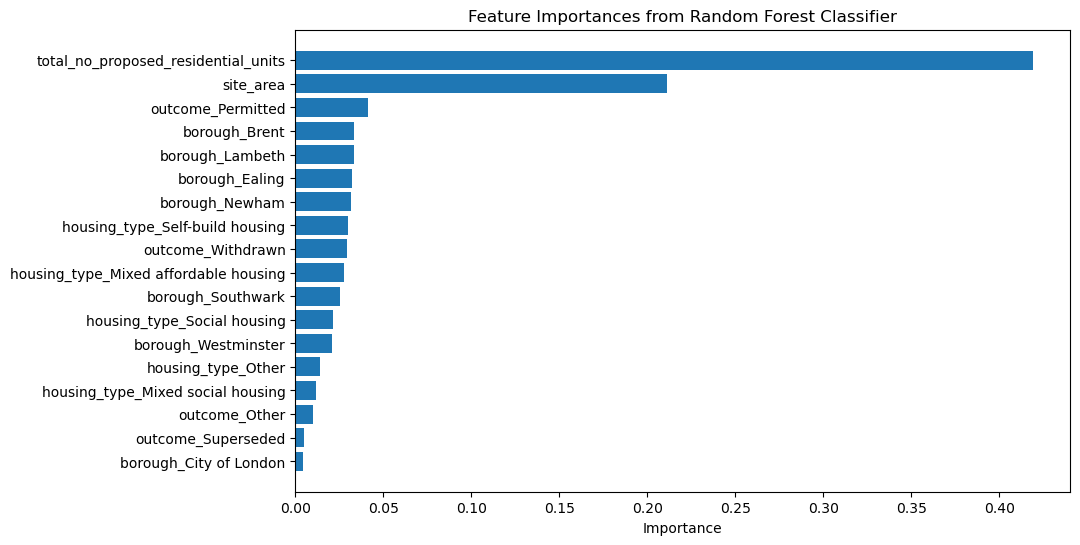

In [15]:
importances = rf.feature_importances_
feature_names = X.columns

# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.66      0.76      0.71       626
           2       0.00      0.00      0.00         5
           3       0.16      0.06      0.08        90

   micro avg       0.64      0.65      0.64       744
   macro avg       0.21      0.20      0.20       744
weighted avg       0.58      0.65      0.61       744
 samples avg       0.46      0.46      0.46       744



/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

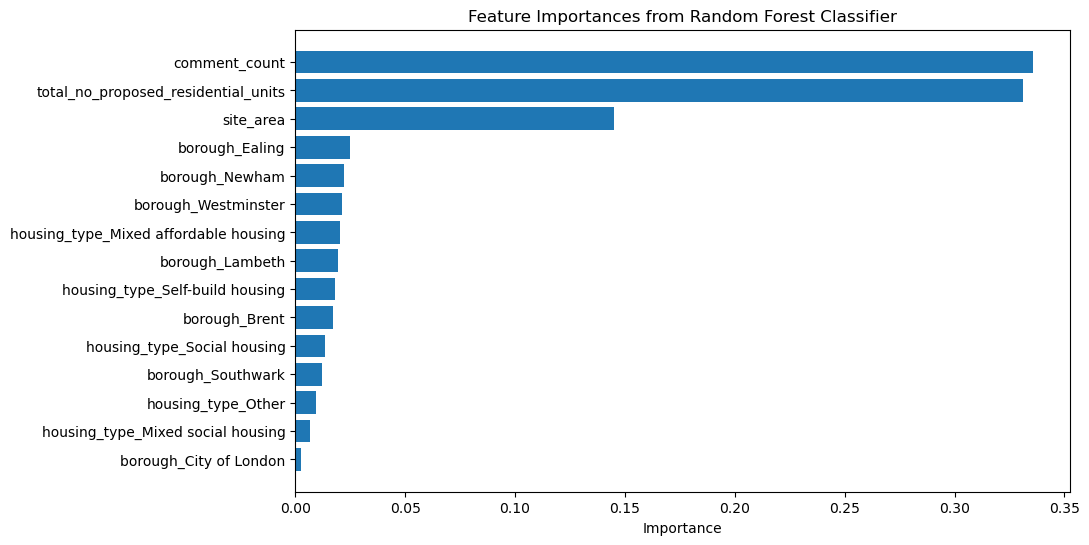

In [16]:
# predict whether an application will be approved based on other features using random forest classifier

# define features and target variable
features = ['total_no_proposed_residential_units', 'borough', 'site_area', 'housing_type', 'comment_count']
X = df[features]
y = df['outcome']
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['housing_type', 'borough'], drop_first=True)
y = pd.get_dummies(y, drop_first=True)
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# make predictions
y_pred = rf.predict(X_test)
# evaluate model
# print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

importances = rf.feature_importances_
feature_names = X.columns
# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

### XGBoost model 

In [ ]:
# define features 
features = ['total_no_proposed_residential_units', 'outcome', 'borough', 'site_area', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']

# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

In [20]:
X.dtypes

total_no_proposed_residential_units       int64
outcome                                category
borough                                category
site_area                               float64
housing_type                           category
dtype: object

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create regression matrices - these are xgb.DMatrix objects
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [31]:
# Define hyperparameters
params = {"objective": "reg:squarederror", "tree_method": "hist"}

evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

n = 100
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals
)

[0]	train-rmse:0.48061	validation-rmse:0.48725
[1]	train-rmse:0.46967	validation-rmse:0.48263
[2]	train-rmse:0.46324	validation-rmse:0.48154
[3]	train-rmse:0.45905	validation-rmse:0.48081
[4]	train-rmse:0.45609	validation-rmse:0.48103
[5]	train-rmse:0.45432	validation-rmse:0.48139
[6]	train-rmse:0.45205	validation-rmse:0.48123
[7]	train-rmse:0.44991	validation-rmse:0.48187
[8]	train-rmse:0.44835	validation-rmse:0.48225
[9]	train-rmse:0.44690	validation-rmse:0.48230
[10]	train-rmse:0.44583	validation-rmse:0.48269
[11]	train-rmse:0.44471	validation-rmse:0.48325
[12]	train-rmse:0.44324	validation-rmse:0.48302
[13]	train-rmse:0.44295	validation-rmse:0.48319
[14]	train-rmse:0.44124	validation-rmse:0.48351
[15]	train-rmse:0.44056	validation-rmse:0.48304
[16]	train-rmse:0.43960	validation-rmse:0.48321
[17]	train-rmse:0.43943	validation-rmse:0.48326
[18]	train-rmse:0.43887	validation-rmse:0.48354
[19]	train-rmse:0.43808	validation-rmse:0.48366
[20]	train-rmse:0.43670	validation-rmse:0.48443
[2

In [33]:
results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=20
)

results.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,0.480063,0.000772,0.485836,0.000885
1,0.468807,0.000840,0.479122,0.001346
2,0.461723,0.000757,0.476159,0.002113
3,0.457017,0.000759,0.475598,0.002484
4,0.453594,0.000903,0.475420,0.002147


In [34]:
best_rmse = results['test-rmse-mean'].min()

best_rmse

0.4754196819977577